# Task 2: Exploratory Data Analysis on the Titanic Dataset

**Elevvo Pathways — Data Analytics Internship, Task 2 (Level 1)**

**Goal:** explore the classic Titanic dataset, clean it, generate summary statistics
and group-based insights (e.g. survival by gender/class), and visualize key patterns
and correlations.

**Dataset:** [Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)
— 891 real passengers from the April 1912 voyage, sourced from a public GitHub mirror
of the original Kaggle competition data
(`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`).

**Tools:** Python, pandas, seaborn, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

df = pd.read_csv('titanic.csv')
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data Cleaning

Three columns need attention:
- **Age** — 177 missing values (~20%). Filled with the median age *within each
  Pclass + Sex group*, since age varies meaningfully by class and gender — more
  accurate than a single dataset-wide median.
- **Embarked** — only 2 missing values. Filled with the mode (most common port).
- **Cabin** — 687 missing (~77%). Too sparse to impute meaningfully, so instead of
  dropping rows or guessing values, it's converted into a binary `Has_Cabin` flag,
  which turns out to be informative on its own (see correlation heatmap below).


In [2]:
print("Missing values before cleaning:")
print(df.isna().sum())


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Age: median imputation grouped by Pclass + Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin: convert to a Has_Cabin binary flag instead of imputing
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df = df.drop(columns=['Cabin'])

# Type conversions
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Missing values after cleaning:")
print(df.isna().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


## 2. Feature Engineering

Two extra features help the analysis:
- **FamilySize** = SibSp + Parch + 1 (siblings/spouses + parents/children + self)
- **IsAlone** = 1 if travelling alone, 0 otherwise
- **AgeGroup** = Child / Teen / Adult / Senior buckets, for cleaner group comparisons


In [4]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

def age_group(a):
    if a < 13: return 'Child (0-12)'
    if a < 20: return 'Teen (13-19)'
    if a < 60: return 'Adult (20-59)'
    return 'Senior (60+)'

df['AgeGroup'] = df['Age'].apply(age_group)
df.to_csv('titanic_clean.csv', index=False)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,Adult (20-59)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,Adult (20-59)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,Adult (20-59)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,Adult (20-59)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,Adult (20-59)


## 3. Summary Statistics & Group-Based Insights

In [5]:
print(f"Overall survival rate: {df['Survived'].astype(int).mean():.1%}")
df.describe(include='all')


Overall survival rate: 38.4%


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,FamilySize,IsAlone,AgeGroup
count,891.000000,891.0,891.0,891,891,891.000000,891.000000,891.000000,891,891.000000,891,891.000000,891.000000,891.000000,891
unique,NaN,2.0,3.0,891,2,NaN,NaN,NaN,681,NaN,3,NaN,NaN,NaN,4
top,NaN,0.0,3.0,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,S,NaN,NaN,NaN,Adult (20-59)
freq,NaN,549.0,491.0,1,577,NaN,NaN,NaN,7,NaN,646,NaN,NaN,NaN,701
mean,446.000000,NaN,NaN,NaN,NaN,29.112424,0.523008,0.381594,NaN,32.204208,NaN,0.228956,1.904602,0.602694,NaN
std,257.353842,NaN,NaN,NaN,NaN,13.304424,1.102743,0.806057,NaN,49.693429,NaN,0.420397,1.613459,0.489615,NaN
min,1.000000,NaN,NaN,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,1.000000,0.000000,NaN
25%,223.500000,NaN,NaN,NaN,NaN,21.500000,0.000000,0.000000,NaN,7.910400,NaN,0.000000,1.000000,0.000000,NaN
50%,446.000000,NaN,NaN,NaN,NaN,26.000000,0.000000,0.000000,NaN,14.454200,NaN,0.000000,1.000000,1.000000,NaN
75%,668.500000,NaN,NaN,NaN,NaN,36.000000,1.000000,0.000000,NaN,31.000000,NaN,0.000000,2.000000,1.000000,NaN


### Survival rate by Sex

In [6]:
by_sex = df.groupby('Sex', observed=True)['Survived'].apply(lambda x: x.astype(int).mean())
by_sex.round(3)


Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

### Survival rate by Passenger Class

In [7]:
by_class = df.groupby('Pclass', observed=True)['Survived'].apply(lambda x: x.astype(int).mean())
by_class.round(3)


Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

### Survival rate by Sex x Passenger Class (combined)

In [8]:
by_sex_class = df.groupby(['Pclass','Sex'], observed=True)['Survived'].apply(lambda x: x.astype(int).mean()).unstack()
by_sex_class.round(3)


Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


### Survival rate by Age Group

In [9]:
order = ['Child (0-12)','Teen (13-19)','Adult (20-59)','Senior (60+)']
by_age = df.groupby('AgeGroup', observed=True)['Survived'].apply(lambda x: x.astype(int).mean()).reindex(order)
by_age.round(3)


AgeGroup
Child (0-12)     0.580
Teen (13-19)     0.411
Adult (20-59)    0.365
Senior (60+)     0.269
Name: Survived, dtype: float64

### Survival rate: travelling alone vs. with family

In [10]:
by_alone = df.groupby('IsAlone')['Survived'].apply(lambda x: x.astype(int).mean())
by_alone.index = ['With Family', 'Alone']
by_alone.round(3)


With Family    0.506
Alone          0.304
Name: Survived, dtype: float64

### Survival rate by port of embarkation

In [11]:
by_emb = df.groupby('Embarked', observed=True)['Survived'].apply(lambda x: x.astype(int).mean())
by_emb.round(3)


Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64

## 4. Visualizations

### Survival rate by Sex

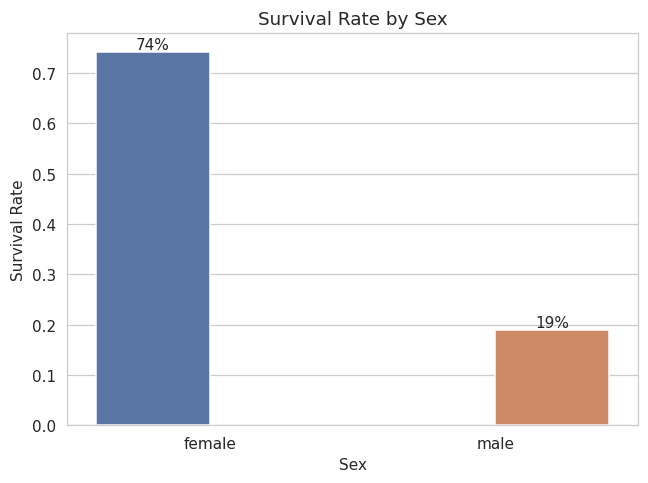

In [12]:
plt.figure(figsize=(6,4.5))
ax = sns.barplot(x='Sex', y=df['Survived'].astype(int), hue='Sex', data=df,
                  palette=['#4C72B0','#DD8452'], estimator=np.mean, errorbar=None, legend=False)
ax.set_ylabel('Survival Rate'); ax.set_title('Survival Rate by Sex')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', labels=[f'{v.get_height():.0%}' for v in c])
plt.tight_layout(); plt.show()


### Survival rate by Passenger Class

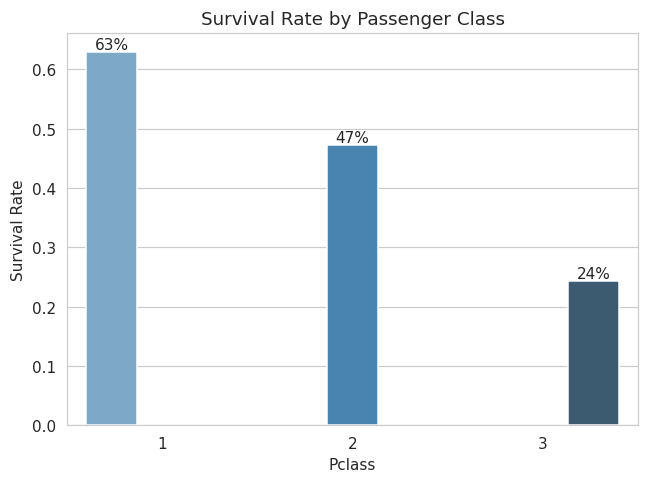

In [13]:
plt.figure(figsize=(6,4.5))
ax = sns.barplot(x='Pclass', y=df['Survived'].astype(int), hue='Pclass', data=df,
                  palette='Blues_d', estimator=np.mean, errorbar=None, legend=False)
ax.set_ylabel('Survival Rate'); ax.set_title('Survival Rate by Passenger Class')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', labels=[f'{v.get_height():.0%}' for v in c])
plt.tight_layout(); plt.show()


### Bonus: Survival rate heatmap (Sex x Passenger Class)

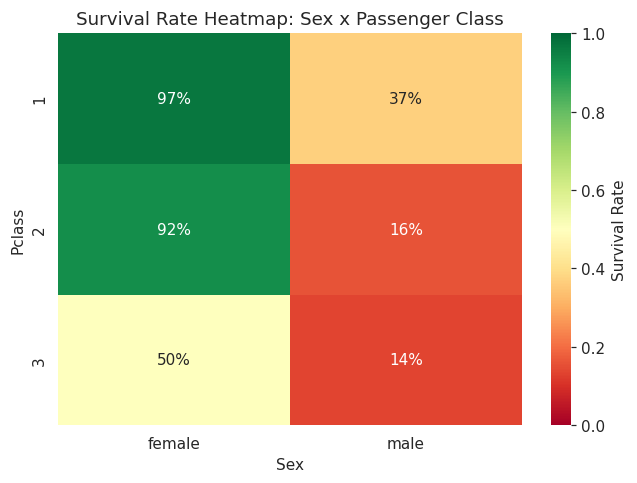

In [14]:
plt.figure(figsize=(6,4.5))
sns.heatmap(by_sex_class, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'Survival Rate'})
plt.title('Survival Rate Heatmap: Sex x Passenger Class')
plt.tight_layout(); plt.show()


### Age distribution by survival outcome

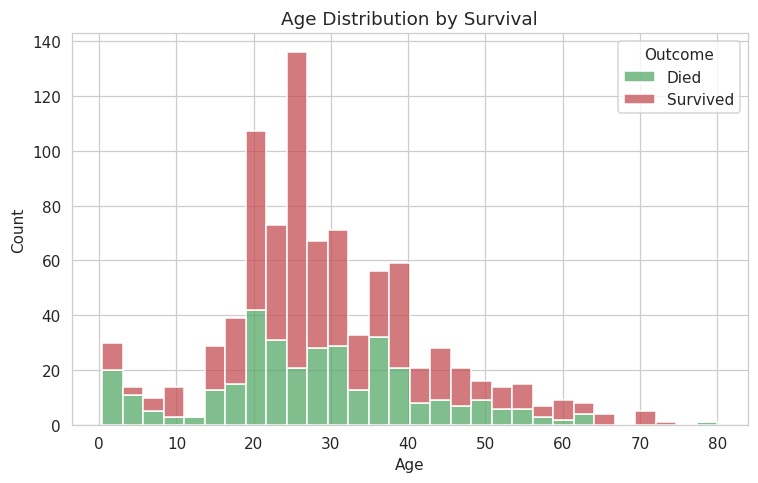

In [15]:
plt.figure(figsize=(7,4.5))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30, palette=['#C44E52','#55A868'])
plt.title('Age Distribution by Survival')
plt.legend(['Died','Survived'], title='Outcome')
plt.tight_layout(); plt.show()


### Fare distribution by class

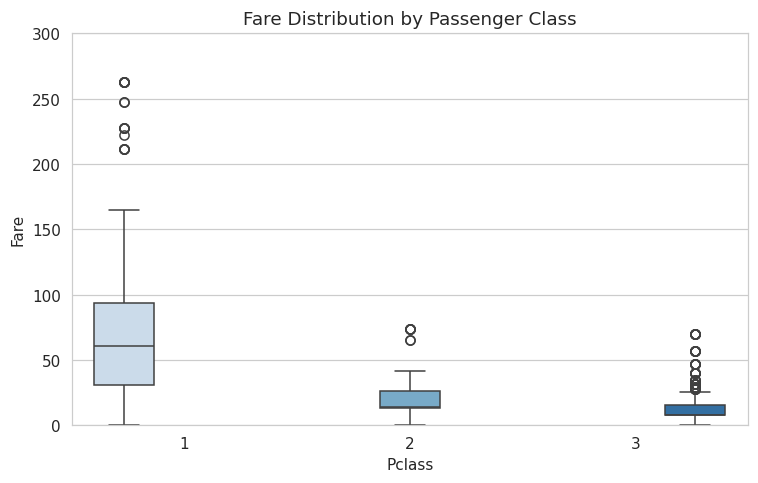

In [16]:
plt.figure(figsize=(7,4.5))
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='Blues', legend=False)
plt.title('Fare Distribution by Passenger Class'); plt.ylim(0,300)
plt.tight_layout(); plt.show()


### Survival rate by family size

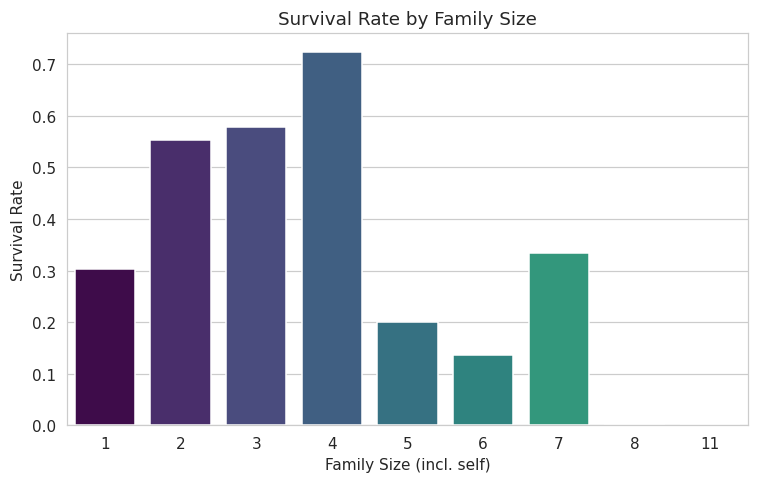

In [17]:
plt.figure(figsize=(7,4.5))
fam_surv = df.groupby('FamilySize')['Survived'].apply(lambda x: x.astype(int).mean())
sns.barplot(x=fam_surv.index, y=fam_surv.values, hue=fam_surv.index, palette='viridis', legend=False)
plt.ylabel('Survival Rate'); plt.xlabel('Family Size (incl. self)')
plt.title('Survival Rate by Family Size')
plt.tight_layout(); plt.show()


### Correlation matrix (numeric features)

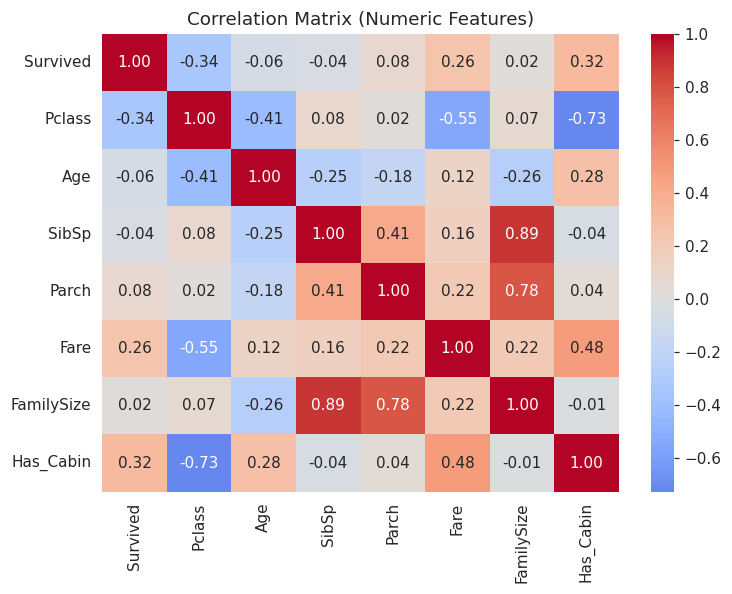

In [18]:
plt.figure(figsize=(7,5.5))
numeric_df = df.copy()
numeric_df['Survived'] = numeric_df['Survived'].astype(int)
numeric_df['Pclass'] = numeric_df['Pclass'].astype(int)
corr = numeric_df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize','Has_Cabin']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout(); plt.show()


### Survival rate by age group

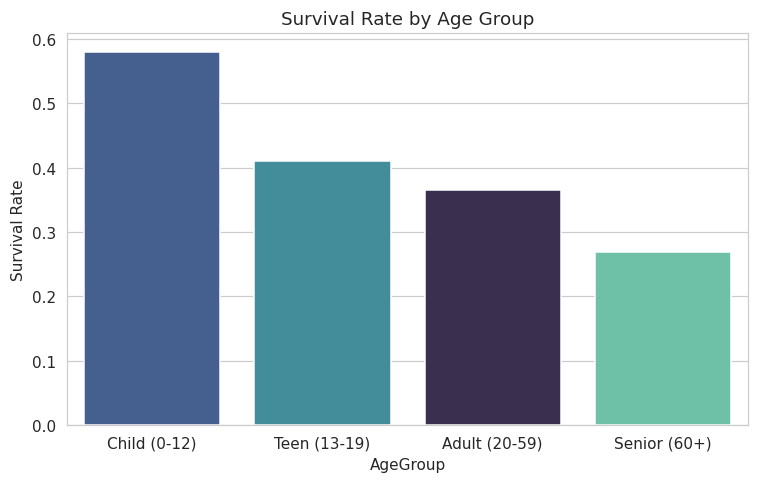

In [19]:
plt.figure(figsize=(7,4.5))
sns.barplot(x='AgeGroup', y=df['Survived'].astype(int), hue='AgeGroup', data=df, order=order,
            palette='mako', estimator=np.mean, errorbar=None, legend=False)
plt.ylabel('Survival Rate'); plt.title('Survival Rate by Age Group')
plt.tight_layout(); plt.show()


## 5. Key Insights

1. **Sex was the single strongest predictor of survival.** Women survived at
   **74.2%** vs. just **18.9%** for men — consistent with a "women and children
   first" evacuation policy.
2. **Class mattered almost as much as sex, and the two compound.** 1st class
   women survived at **96.8%**, while 3rd class men survived at only **13.5%** —
   an 83-point gap driven by the combination of both factors.
3. **Fare and class are tightly linked**, and both correlate with survival —
   passengers who paid more (mostly 1st class) had faster access to lifeboats.
4. **Travelling alone hurt survival odds** (30.4% alone vs. 50.6% with family) —
   small family groups may have helped each other reach lifeboats, though very
   large families (5+) saw survival drop again, likely because large groups were
   harder to keep together during evacuation.
5. **Children had a meaningfully higher survival rate** (57.9%) than adults
   (36.5%) or seniors (26.9%), again consistent with the evacuation policy.
6. **`Has_Cabin` correlates with survival** — passengers with a recorded cabin
   number (mostly 1st/2nd class) survived more often, reinforcing the class effect
   even through a feature built entirely from missing data.

**Bottom line:** survival on the Titanic was not random — it was shaped heavily
by who you were (sex, age) and what you could afford (class, fare, cabin access).
